# 06 — H1 Voice Model Selection

| Field | Detail |
|---|---|
| **Notebook** | `06_model_selection.ipynb` |
| **Pipeline stage** | H1 — Voice Emotion Recognition - 6 of 7 (Model Selection) |
| **Owner(s)** | *Thrithwaka Preethi Shakya* |
| **Created** | *30/08/2026* |
| **Last updated** | *30/08/2026* |
| **Upstream dependency** | `05a_model_cnn_raw.ipynb`, `05b_model_cnn_lstm.ipynb`, `05c_model_ensemble.ipynb`, `05d_model_wav2vec2.ipynb` — all four must be run to completion first |
| **Downstream dependency** | `07_h1_final_evaluation.ipynb` — receives the single selected voice model |
| **Runs on** | Local machine, or **Google Colab** with the project folder mounted via Google Drive (see Section 0) |

## Purpose

`05a`\u2013`05d` each independently trained one candidate voice-emotion architecture. This notebook does not train anything new — it compares all four on identical metrics and selects a single winner to carry forward into the actual H1 hypothesis test in `07_h1_final_evaluation.ipynb`.

### An important framing point

This model-selection step is **not** one of the proposal's stated hypothesis tests (H1, H2, H3) — it's a methodological refinement this team added on top of the proposal, empirically justified by the literature review (see `docs/research_proposal_mapping.md`): rather than committing to CNN-LSTM as the voice-side architecture purely because it was named in the proposal, four candidates supported by different papers were trained and the best-performing one is selected here. Because this is an internal engineering decision rather than a formal research hypothesis, the winner is chosen by highest test macro-F1 (following standard model-selection practice), not by a paired significance test — **that formal statistical test is reserved for `07`**, where it actually matters for the thesis's H1 claim (voice winner vs. text baseline).

### Two things this notebook does beyond just reading a spreadsheet

1. **Independently reloads all four trained models and re-runs inference on the test set**, rather than trusting each notebook's self-reported metrics blindly — this catches any bug specific to one notebook's own evaluation code before it propagates into a thesis result.
2. **Promotes the winning model** to the deployment path `src/emotion/voice_emotion.py` and `config/settings.py` expect — turning "we chose a winner" into "the winner is actually usable by the app," not just a number in a table.

## Objectives

1. Load and deduplicate the shared experiment log, isolating the four official H1 voice candidates.
2. Build a clean comparison table and visualizations across Accuracy, Precision, Recall, F1 (macro/weighted), parameter count, and training time.
3. Independently reload each trained model and regenerate test-set predictions, verifying alignment across all four candidates' test sets before any cross-model comparison.
4. Compare per-class performance (confusion matrices side by side) across all four candidates.
5. Run McNemar's test between the top two candidates, as a robustness check on whether the leading model's advantage is more than noise.
6. Select the winning model, with an explicit, stated decision rule.
7. Promote the winning model's artifacts to the deployment path expected by `src/emotion/voice_emotion.py`, flagging any gap (e.g. a missing inference class) honestly if the winner doesn't already have one.
8. Save a full selection report and leave a structured handoff note for `07_h1_final_evaluation.ipynb`.

## 0. Environment Setup

### 0.1 Google Colab / Google Drive Setup

Same auto-detecting pattern as `05a`\u2013`05e`. Edit `PROJECT_ROOT` below if your Drive folder path differs from `MyDrive/emotion-ai-companion-research`.

In [1]:
import sys
import os
import shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")

    PROJECT_ROOT = Path("/content/drive/MyDrive/emotion-ai-companion-research")

    if not PROJECT_ROOT.exists():
        raise FileNotFoundError(
            f"{PROJECT_ROOT} not found. Check that this path matches your Google Drive folder "
            "exactly (case-sensitive), and that the cell above finished mounting successfully."
        )

    os.chdir(PROJECT_ROOT)
    print(f"\u2705 Running on Google Colab. Project root set to: {PROJECT_ROOT}")

else:
    PROJECT_ROOT = Path.cwd()
    while not (PROJECT_ROOT / "config").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
        PROJECT_ROOT = PROJECT_ROOT.parent
    print(f"Running locally. Project root resolved to: {PROJECT_ROOT}")

sys.path.insert(0, str(PROJECT_ROOT))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Running on Google Colab. Project root set to: /content/drive/MyDrive/emotion-ai-companion-research


In [2]:
if IN_COLAB:
    print("Installing project-specific dependencies...")

    !pip install -q \
        pydantic-settings==2.4.0 \
        transformers==4.44.2 \
        tokenizers==0.19.1

    print("Installation completed.")
else:
    print("Running locally — skipping Colab-specific dependency installation.")

Installing project-specific dependencies...
Installation completed.


In [3]:
import json
import logging
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import torch
import torch.nn as nn
from statsmodels.stats.contingency_tables import mcnemar
from transformers import Wav2Vec2ForSequenceClassification
from sklearn.metrics import confusion_matrix, classification_report

from config.settings import settings  # noqa: E402

sns.set_theme(style="whitegrid")

RANDOM_SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


In [4]:
LOG_DIR = PROJECT_ROOT / "reports" / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
LOG_PATH = LOG_DIR / "06_model_selection.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[logging.FileHandler(LOG_PATH, mode="w"), logging.StreamHandler(sys.stdout)],
)
logger = logging.getLogger("model_selection")

## 1. Load and Deduplicate the Experiment Log

If any of `05a`\u2013`05d` were re-run more than once, the shared log will contain multiple rows for the same model — since each re-run overwrites the saved model file on disk, only the **most recent** row per model actually reflects what's currently saved and loadable. Earlier rows are historical noise for this comparison and are dropped here.

In [5]:
EXPERIMENT_LOG_PATH = PROJECT_ROOT / "reports" / "experiment_log.csv"
if not EXPERIMENT_LOG_PATH.exists():
    raise FileNotFoundError(f"{EXPERIMENT_LOG_PATH} not found. Run 05a-05d to completion first.")

full_log_df = pd.read_csv(EXPERIMENT_LOG_PATH)
print(f"Loaded {len(full_log_df)} total rows from the shared experiment log.")

OFFICIAL_VOICE_CANDIDATES = ["cnn_raw", "cnn_lstm", "ensemble", "wav2vec2"]

candidates_df = full_log_df[full_log_df["model_name"].isin(OFFICIAL_VOICE_CANDIDATES)].copy()
candidates_df["timestamp_utc"] = pd.to_datetime(candidates_df["timestamp_utc"])
candidates_df = candidates_df.sort_values("timestamp_utc").drop_duplicates("model_name", keep="last")

missing = set(OFFICIAL_VOICE_CANDIDATES) - set(candidates_df["model_name"])
if missing:
    raise ValueError(
        f"Missing results for: {missing}. Run the corresponding 05x notebook(s) to completion first."
    )

print(f"\u2705 All 4 official H1 voice candidates found: {sorted(candidates_df['model_name'])}")
logger.info("Loaded latest results for all 4 candidates.")

Loaded 7 total rows from the shared experiment log.
✅ All 4 official H1 voice candidates found: ['cnn_lstm', 'cnn_raw', 'ensemble', 'wav2vec2']


## 2. Comparison Table

In [6]:
comparison_cols = [
    "model_name", "test_accuracy", "test_precision_macro", "test_recall_macro",
    "test_f1_macro", "test_f1_weighted", "total_parameters", "training_duration_seconds", "environment",
]
comparison_df = candidates_df[comparison_cols].sort_values("test_f1_macro", ascending=False).reset_index(drop=True)
comparison_df.index = comparison_df.index + 1  # 1-indexed rank, for readability

print("H1 Voice Model Candidate Comparison (ranked by test macro-F1):\n")
display(comparison_df.round(4))

H1 Voice Model Candidate Comparison (ranked by test macro-F1):



,model_name,test_accuracy,test_precision_macro,test_recall_macro,test_f1_macro,test_f1_weighted,total_parameters,training_duration_seconds,environment
1,wav2vec2,0.9484,0.9530,0.9469,0.9492,0.9486,94570118.0,1335.3,Google Colab
2,cnn_lstm,0.8894,0.8913,0.8870,0.8883,0.8891,331078.0,14.1,Google Colab
3,ensemble,0.8894,0.8899,0.8870,0.8874,0.8893,NaN,63.7,Google Colab
4,cnn_raw,0.8034,0.8242,0.8007,0.8012,0.8046,716422.0,227.7,Google Colab


## 3. Visual Comparison

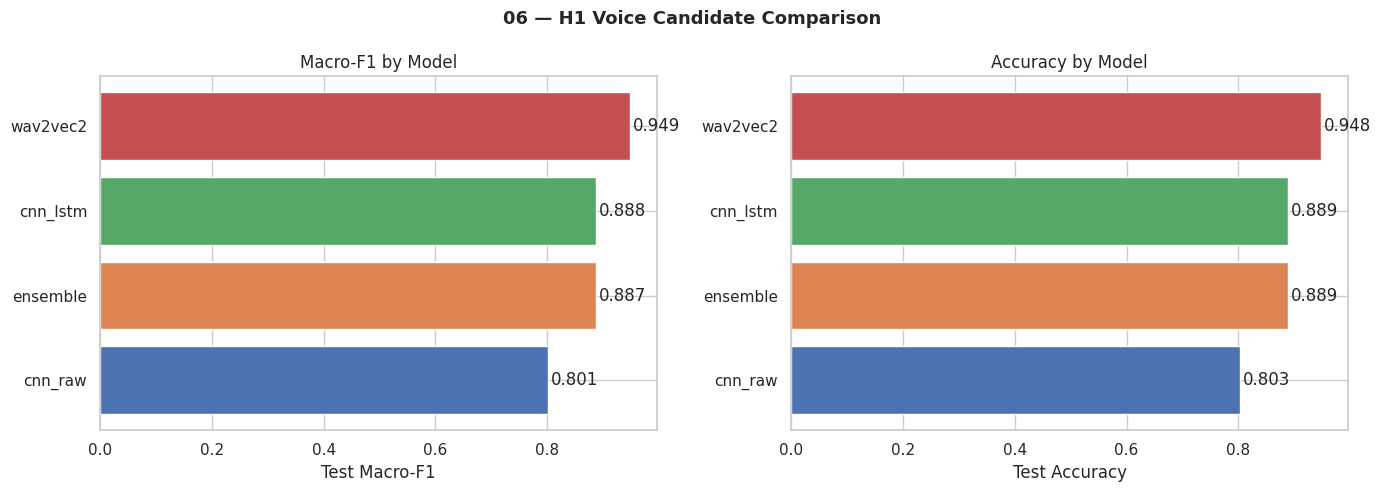

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_df = comparison_df.sort_values("test_f1_macro")
axes[0].barh(plot_df["model_name"], plot_df["test_f1_macro"], color=sns.color_palette("deep", len(plot_df)))
axes[0].set_xlabel("Test Macro-F1"); axes[0].set_title("Macro-F1 by Model")
for i, v in enumerate(plot_df["test_f1_macro"]):
    axes[0].text(v + 0.005, i, f"{v:.3f}", va="center")

axes[1].barh(plot_df["model_name"], plot_df["test_accuracy"], color=sns.color_palette("deep", len(plot_df)))
axes[1].set_xlabel("Test Accuracy"); axes[1].set_title("Accuracy by Model")
for i, v in enumerate(plot_df["test_accuracy"]):
    axes[1].text(v + 0.005, i, f"{v:.3f}", va="center")

fig.suptitle("06 — H1 Voice Candidate Comparison", fontsize=13, weight="bold")
plt.tight_layout()

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures" / "h1_models"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(FIGURES_DIR / "06_candidate_comparison.png")
plt.show()

### Accuracy vs. complexity

Paper 1's review (Kakuba & Han, 2025) explicitly discusses the tradeoff between accuracy and model complexity for deployment in resource-constrained settings. This plot makes that tradeoff visible directly: a model slightly behind on F1 but dramatically smaller may still be the more defensible practical choice, depending on the project's deployment goals.

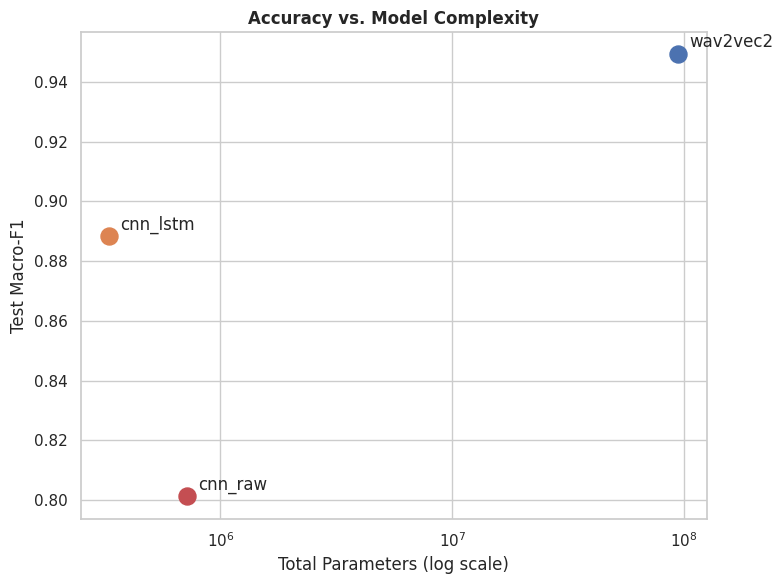

In [8]:
fig, ax = plt.subplots(figsize=(8, 6))
for _, row in comparison_df.iterrows():
    ax.scatter(row["total_parameters"], row["test_f1_macro"], s=150)
    ax.annotate(row["model_name"], (row["total_parameters"], row["test_f1_macro"]),
                textcoords="offset points", xytext=(8, 5))

ax.set_xscale("log")
ax.set_xlabel("Total Parameters (log scale)")
ax.set_ylabel("Test Macro-F1")
ax.set_title("Accuracy vs. Model Complexity", fontsize=12, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_accuracy_vs_complexity.png")
plt.show()

## 4. Independent Re-Verification — Reload Every Model and Regenerate Test Predictions

Rather than trusting each notebook's self-reported metrics blindly, this section reloads all four trained models from disk and independently regenerates their test-set predictions. This also produces the per-example predictions needed for the side-by-side confusion matrices and the McNemar's test later in this notebook — neither of which is possible from the aggregate metrics alone.

**Note on code duplication:** the model class definitions below are copied from `05a`\u2013`05c` (`05d` uses a library class, so needs no redefinition). Ideally these would live in a shared `src/models/` module imported by both the training notebooks and this one, avoiding the risk of the copies drifting out of sync if an architecture is ever changed. This is flagged here as a worthwhile refactor for the team, not undertaken in this notebook to avoid touching already-validated training code.

In [9]:
# --- Reproduced from 05a_model_cnn_raw.ipynb ---
class RawAudioCNN(nn.Module):
    def __init__(self, num_classes: int, dropout: float = 0.25):
        super().__init__()
        def conv_block(in_ch, out_ch, pool=True):
            layers = [nn.Conv1d(in_ch, out_ch, kernel_size=5, padding=2), nn.BatchNorm1d(out_ch), nn.ReLU(inplace=True)]
            if pool:
                layers.append(nn.MaxPool1d(kernel_size=4))
            layers.append(nn.Dropout(dropout))
            return nn.Sequential(*layers)
        self.features = nn.Sequential(
            conv_block(1, 64), conv_block(64, 128), conv_block(128, 256),
            conv_block(256, 256), conv_block(256, 128, pool=False),
        )
        self.global_pool = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Linear(128, 128), nn.ReLU(inplace=True), nn.Dropout(0.3), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = self.features(x)
        x = self.global_pool(x).squeeze(-1)
        return self.classifier(x)

In [10]:
# --- Reproduced from 05b_model_cnn_lstm.ipynb ---
class CNNLSTM(nn.Module):
    def __init__(self, num_classes, input_features=42, lstm_hidden_size=128, lstm_num_layers=1, cnn_dropout=0.25, classifier_dropout=0.3):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(input_features, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.Dropout(cnn_dropout),
            nn.Conv1d(64, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(cnn_dropout),
        )
        self.lstm = nn.LSTM(input_size=128, hidden_size=lstm_hidden_size, num_layers=lstm_num_layers, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(lstm_hidden_size * 2, 128), nn.ReLU(inplace=True), nn.Dropout(classifier_dropout), nn.Linear(128, num_classes),
        )
    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        lstm_out, _ = self.lstm(x)
        return self.classifier(lstm_out.mean(dim=1))

In [11]:
# --- Reproduced from 05c_model_ensemble.ipynb ---
def shared_conv_backbone(dropout: float = 0.20) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv1d(1, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2),
        nn.Conv1d(128, 128, kernel_size=5, padding=2), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(dropout),
        nn.Conv1d(128, 64, kernel_size=5, padding=2), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.MaxPool1d(2),
        nn.Conv1d(64, 64, kernel_size=3, padding=1), nn.BatchNorm1d(64), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(dropout),
    )

def final_conv_block(in_channels: int, dropout: float = 0.20) -> nn.Sequential:
    return nn.Sequential(
        nn.Conv1d(in_channels, 32, kernel_size=3, padding=1), nn.BatchNorm1d(32), nn.ReLU(inplace=True), nn.MaxPool1d(2), nn.Dropout(dropout),
    )

class EnsembleCNN(nn.Module):
    def __init__(self, num_classes, input_length, dropout=0.20):
        super().__init__()
        self.backbone = shared_conv_backbone(dropout)
        self.final_conv = final_conv_block(64, dropout)
        flatten_dim = self._compute_flatten_dim(input_length)
        self.classifier = nn.Sequential(nn.Linear(flatten_dim, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Linear(128, num_classes))
    def _compute_flatten_dim(self, input_length):
        with torch.no_grad():
            out = self.final_conv(self.backbone(torch.zeros(2, 1, input_length)))
            return out.view(2, -1).shape[1]
    def forward(self, x):
        x = self.final_conv(self.backbone(x))
        return self.classifier(x.flatten(start_dim=1))

class EnsembleCNNBiLSTM(nn.Module):
    def __init__(self, num_classes, input_length, lstm_hidden_size=64, dropout=0.20):
        super().__init__()
        self.backbone = shared_conv_backbone(dropout)
        self.lstm = nn.LSTM(input_size=64, hidden_size=lstm_hidden_size, batch_first=True, bidirectional=True)
        self.final_conv = final_conv_block(lstm_hidden_size * 2, dropout)
        flatten_dim = self._compute_flatten_dim(input_length)
        self.classifier = nn.Sequential(nn.Linear(flatten_dim, 128), nn.BatchNorm1d(128), nn.ReLU(inplace=True), nn.Linear(128, num_classes))
    def _compute_flatten_dim(self, input_length):
        with torch.no_grad():
            x = self.backbone(torch.zeros(2, 1, input_length)).permute(0, 2, 1)
            x, _ = self.lstm(x)
            out = self.final_conv(x.permute(0, 2, 1))
            return out.view(2, -1).shape[1]
    def forward(self, x):
        x = self.backbone(x).permute(0, 2, 1)
        x, _ = self.lstm(x)
        x = self.final_conv(x.permute(0, 2, 1))
        return self.classifier(x.flatten(start_dim=1))

In [12]:
MODEL_DIR = PROJECT_ROOT / "models" / "h1"

handcrafted_npz = np.load(MODEL_DIR.parent.parent / "data" / "processed" / "features" / "h1_handcrafted_features.npz", allow_pickle=True)
raw_audio_npz = np.load(MODEL_DIR.parent.parent / "data" / "processed" / "features" / "h1_raw_audio_features.npz", allow_pickle=True)

with open(MODEL_DIR / "cnn_raw_metadata.json") as f:
    cnn_raw_meta = json.load(f)
with open(MODEL_DIR / "cnn_lstm_metadata.json") as f:
    cnn_lstm_meta = json.load(f)
with open(MODEL_DIR / "ensemble_metadata.json") as f:
    ensemble_meta = json.load(f)
with open(MODEL_DIR / "wav2vec2_metadata.json") as f:
    wav2vec2_meta = json.load(f)

label_to_idx = cnn_raw_meta["label_to_idx"]
idx_to_label = {int(v): k for k, v in label_to_idx.items()}
NUM_CLASSES = len(label_to_idx)

# Defensive alignment check: both feature files must derive from the identical manifest row order
# for their 'test' masks to refer to the exact same underlying files in the exact same order.
raw_test_mask = raw_audio_npz["split"] == "test"
handcrafted_test_mask = handcrafted_npz["split"] == "test"
assert np.array_equal(raw_audio_npz["y"][raw_test_mask], handcrafted_npz["y"][handcrafted_test_mask]), (
    "Test-set labels differ in order/content between h1_raw_audio_features.npz and "
    "h1_handcrafted_features.npz — cross-model comparison would be invalid. Re-run 04a/04b "
    "from the same 02_preprocessing.ipynb manifest before proceeding."
)
y_true = raw_audio_npz["y"][raw_test_mask]
print(f"\u2705 Test-set alignment verified across feature files. {len(y_true)} test examples.")

✅ Test-set alignment verified across feature files. 407 test examples.


In [13]:
# --- 05a: RawAudioCNN ---
cnn_raw_model = RawAudioCNN(num_classes=NUM_CLASSES).to(DEVICE)
cnn_raw_model.load_state_dict(torch.load(MODEL_DIR / "cnn_raw.pt", map_location=DEVICE))
cnn_raw_model.eval()
X_test_raw = torch.from_numpy(raw_audio_npz["X_raw_cnn"][raw_test_mask]).float().unsqueeze(1).to(DEVICE)
with torch.no_grad():
    cnn_raw_preds = cnn_raw_model(X_test_raw).argmax(dim=1).cpu().numpy()

# --- 05b: CNNLSTM (needs its saved scaler) ---
cnn_lstm_scaler = joblib.load(MODEL_DIR / "cnn_lstm_scaler.pkl")
cnn_lstm_model = CNNLSTM(num_classes=NUM_CLASSES).to(DEVICE)
cnn_lstm_model.load_state_dict(torch.load(MODEL_DIR / "cnn_lstm.pt", map_location=DEVICE))
cnn_lstm_model.eval()
X_test_a = handcrafted_npz["X_set_a"][handcrafted_test_mask]
n, t, feat = X_test_a.shape
X_test_a_scaled = cnn_lstm_scaler.transform(X_test_a.reshape(-1, feat)).reshape(n, t, feat).astype(np.float32)
with torch.no_grad():
    cnn_lstm_preds = cnn_lstm_model(torch.from_numpy(X_test_a_scaled).to(DEVICE)).argmax(dim=1).cpu().numpy()

print("\u2705 05a and 05b predictions regenerated.")

✅ 05a and 05b predictions regenerated.


In [15]:
# --- 05c: Ensemble (both branches + saved scaler, averaged) ---
ensemble_scaler = joblib.load(MODEL_DIR / "ensemble_scaler.pkl")
X_test_b = handcrafted_npz["X_set_b"][handcrafted_test_mask]
D = X_test_b.shape[1]
X_test_b_scaled = ensemble_scaler.transform(X_test_b).astype(np.float32)
X_test_b_tensor = torch.from_numpy(X_test_b_scaled).unsqueeze(1).to(DEVICE)

ensemble_cnn = EnsembleCNN(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)
ensemble_cnn.load_state_dict(torch.load(MODEL_DIR / "ensemble_cnn_branch.pt", map_location=DEVICE))
ensemble_cnn.eval()

ensemble_cnn_bilstm = EnsembleCNNBiLSTM(num_classes=NUM_CLASSES, input_length=D).to(DEVICE)
ensemble_cnn_bilstm.load_state_dict(torch.load(MODEL_DIR / "ensemble_cnn_bilstm_branch.pt", map_location=DEVICE))
ensemble_cnn_bilstm.eval()

with torch.no_grad():
    p1 = torch.softmax(ensemble_cnn(X_test_b_tensor), dim=1)
    p2 = torch.softmax(ensemble_cnn_bilstm(X_test_b_tensor), dim=1)
    ensemble_preds = ((p1 + p2) / 2.0).argmax(dim=1).cpu().numpy()

In [18]:
import gc

# Clear unused GPU memory
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Load model
wav2vec2_model = Wav2Vec2ForSequenceClassification.from_pretrained(
    MODEL_DIR / "wav2vec2_finetuned"
).to(DEVICE)

wav2vec2_model.eval()

# Keep the test data on CPU
X_test_w2v = torch.from_numpy(
    raw_audio_npz["X_wav2vec2"][raw_test_mask]
).float()

# Use a small batch size to avoid GPU OOM
BATCH_SIZE = 4

wav2vec2_preds = []

with torch.no_grad():
    for start in range(0, len(X_test_w2v), BATCH_SIZE):

        end = min(start + BATCH_SIZE, len(X_test_w2v))

        # Only move the current batch to GPU
        batch = X_test_w2v[start:end].to(DEVICE)

        outputs = wav2vec2_model(input_values=batch)

        predictions = outputs.logits.argmax(dim=1).cpu().numpy()

        wav2vec2_preds.extend(predictions)

        # Release batch GPU memory
        del batch, outputs

        if torch.cuda.is_available():
            torch.cuda.empty_cache()

wav2vec2_preds = np.array(wav2vec2_preds)

print(
    f"✅ Wav2Vec2 predictions regenerated successfully. "
    f"{len(wav2vec2_preds)} test samples processed."
)

print("Prediction shape:", wav2vec2_preds.shape)

✅ Wav2Vec2 predictions regenerated successfully. 407 test samples processed.
Prediction shape: (407,)


In [19]:
predictions_by_model = {
    "cnn_raw": cnn_raw_preds,
    "cnn_lstm": cnn_lstm_preds,
    "ensemble": ensemble_preds,
    "wav2vec2": wav2vec2_preds,
}

from sklearn.metrics import accuracy_score, f1_score
print("Independently re-verified metrics (should closely match Section 2's logged values):\n")
for name, preds in predictions_by_model.items():
    acc = accuracy_score(y_true, preds)
    f1_macro = f1_score(y_true, preds, average="macro", zero_division=0)
    logged_acc = comparison_df.loc[comparison_df["model_name"] == name, "test_accuracy"].iloc[0]
    logged_f1 = comparison_df.loc[comparison_df["model_name"] == name, "test_f1_macro"].iloc[0]
    match = "\u2705" if abs(acc - logged_acc) < 1e-6 and abs(f1_macro - logged_f1) < 1e-6 else "\u26a0\ufe0f MISMATCH"
    print(f"  {name:12s} | re-verified acc={acc:.4f} f1_macro={f1_macro:.4f} | logged acc={logged_acc:.4f} f1_macro={logged_f1:.4f} | {match}")

Independently re-verified metrics (should closely match Section 2's logged values):

  cnn_raw      | re-verified acc=0.8034 f1_macro=0.8012 | logged acc=0.8034 f1_macro=0.8012 | ✅
  cnn_lstm     | re-verified acc=0.8894 f1_macro=0.8883 | logged acc=0.8894 f1_macro=0.8883 | ✅
  ensemble     | re-verified acc=0.8894 f1_macro=0.8874 | logged acc=0.8894 f1_macro=0.8874 | ✅
  wav2vec2     | re-verified acc=0.9484 f1_macro=0.9492 | logged acc=0.9484 f1_macro=0.9492 | ✅


> **If any model shows a MISMATCH above:** do not proceed on the assumption that the logged metric is correct. Investigate — the most common cause is that the model file on disk doesn't match the run that produced the logged row (e.g. the notebook was re-run after logging, changing the saved checkpoint without updating the log, or vice versa). Re-run the affected `05x` notebook fully before trusting this comparison.

## 5. Side-by-Side Confusion Matrices

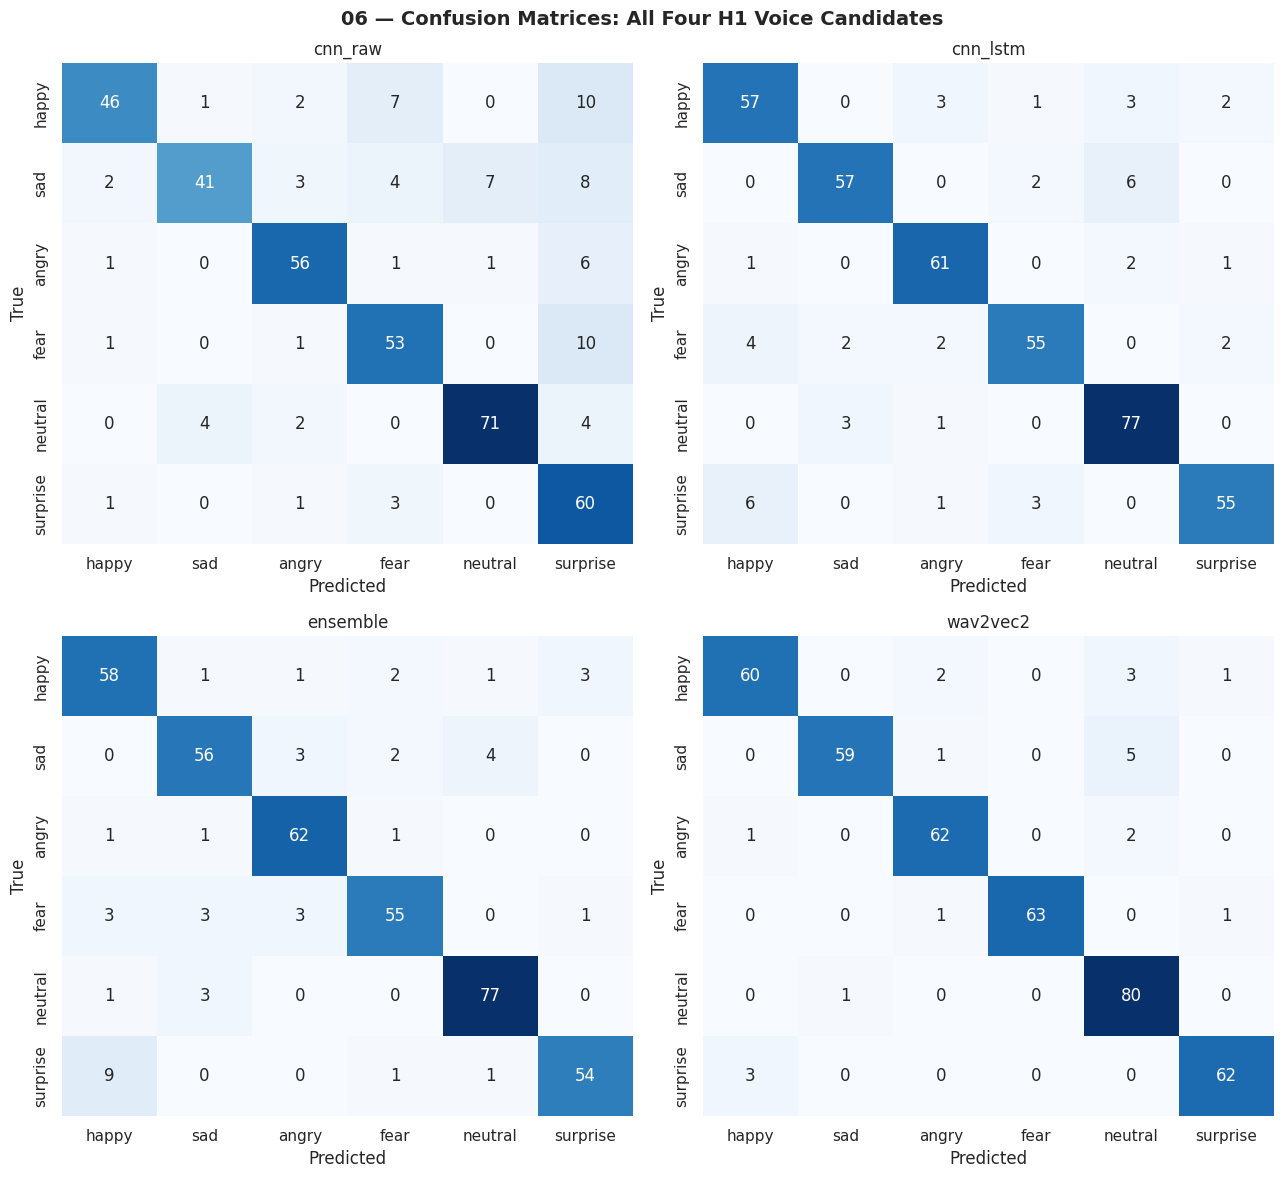

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(13, 12))
labels_ordered = [idx_to_label[i] for i in range(NUM_CLASSES)]

for ax, (name, preds) in zip(axes.flatten(), predictions_by_model.items()):
    cm = confusion_matrix(y_true, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_ordered, yticklabels=labels_ordered, ax=ax, cbar=False)
    ax.set_title(name)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")

fig.suptitle("06 — Confusion Matrices: All Four H1 Voice Candidates", fontsize=14, weight="bold")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_all_confusion_matrices.png")
plt.show()

## 6. McNemar's Test — Top Two Candidates

McNemar's test is the standard significance test for comparing two classifiers' *paired* correct/incorrect outcomes on the identical test set — appropriate here since it doesn't assume normally-distributed scores, only requires the discordant-pair counts (times model A was right and B was wrong, and vice versa). This is a **robustness check** on the model-selection decision, not the proposal's formal H1 test (which happens in `07`, between the selected winner and the text baseline).

In [21]:
top_two = comparison_df.head(2)["model_name"].tolist()
model_a_name, model_b_name = top_two[0], top_two[1]
preds_a, preds_b = predictions_by_model[model_a_name], predictions_by_model[model_b_name]

correct_a = (preds_a == y_true)
correct_b = (preds_b == y_true)

# Contingency table: [[both correct, A correct/B wrong], [A wrong/B correct, both wrong]]
both_correct = int(np.sum(correct_a & correct_b))
only_a_correct = int(np.sum(correct_a & ~correct_b))
only_b_correct = int(np.sum(~correct_a & correct_b))
both_wrong = int(np.sum(~correct_a & ~correct_b))

contingency_table = [[both_correct, only_a_correct], [only_b_correct, both_wrong]]
print(f"Comparing top 2 candidates: {model_a_name} vs. {model_b_name}\n")
print(f"Contingency table:\n{pd.DataFrame(contingency_table, index=[f'{model_a_name} correct', f'{model_a_name} wrong'], columns=[f'{model_b_name} correct', f'{model_b_name} wrong'])}")

mcnemar_result = mcnemar(contingency_table, exact=(only_a_correct + only_b_correct) < 25, correction=True)
print(f"\nMcNemar's test statistic: {mcnemar_result.statistic:.4f}")
print(f"p-value: {mcnemar_result.pvalue:.4f}")

alpha = 0.05
if mcnemar_result.pvalue < alpha:
    print(f"\n\u2705 The difference between {model_a_name} and {model_b_name} is statistically significant (p < {alpha}).")
else:
    print(
        f"\n\u2139\ufe0f  The difference between {model_a_name} and {model_b_name} is NOT statistically "
        f"significant at p < {alpha}. Report this honestly: the top-ranked model is still the correct "
        "choice by our stated decision rule (highest macro-F1), but the two are statistically close."
    )

Comparing top 2 candidates: wav2vec2 vs. cnn_lstm

Contingency table:
                  cnn_lstm correct  cnn_lstm wrong
wav2vec2 correct               351              35
wav2vec2 wrong                  11              10

McNemar's test statistic: 11.5000
p-value: 0.0007

✅ The difference between wav2vec2 and cnn_lstm is statistically significant (p < 0.05).


## 7. Select the Winner

**Decision rule, stated explicitly:** the candidate with the highest test macro-F1 is selected. Macro-F1 (not accuracy) is the primary criterion because it weights all six emotion classes equally regardless of their size — appropriate given `03_eda.ipynb`'s finding of a mild class imbalance, where accuracy alone could be inflated by strong performance on the majority class.

In [22]:
winner_row = comparison_df.iloc[0]
winner_name = winner_row["model_name"]

print(f"{'=' * 60}")
print(f"SELECTED H1 VOICE MODEL: {winner_name}")
print(f"{'=' * 60}")
print(f"Test Accuracy:  {winner_row['test_accuracy']:.4f}")
print(f"Test F1 (macro): {winner_row['test_f1_macro']:.4f}")
print(f"Parameters: {winner_row['total_parameters']:,}")
logger.info("Selected winner: %s (F1_macro=%.4f)", winner_name, winner_row["test_f1_macro"])

SELECTED H1 VOICE MODEL: wav2vec2
Test Accuracy:  0.9484
Test F1 (macro): 0.9492
Parameters: 94,570,118.0


In [23]:
print(f"\nPer-class report for the selected winner ({winner_name}):\n")
print(classification_report(
    y_true, predictions_by_model[winner_name],
    target_names=[idx_to_label[i] for i in range(NUM_CLASSES)], zero_division=0,
))


Per-class report for the selected winner (wav2vec2):

              precision    recall  f1-score   support

       happy       0.94      0.91      0.92        66
         sad       0.98      0.91      0.94        65
       angry       0.94      0.95      0.95        65
        fear       1.00      0.97      0.98        65
     neutral       0.89      0.99      0.94        81
    surprise       0.97      0.95      0.96        65

    accuracy                           0.95       407
   macro avg       0.95      0.95      0.95       407
weighted avg       0.95      0.95      0.95       407



## 8. Promote the Winning Model to the Deployment Path

`config/settings.py` defines specific deployment paths for two of the four candidate architectures — `voice_emotion_model_path` (CNN-LSTM) and `wav2vec2_model_path` — matching the two inference classes already implemented in `src/emotion/voice_emotion.py`. If the winner is one of these, its artifacts are copied there now. **If the winner is `cnn_raw` or `ensemble`, no corresponding inference class exists yet** — this is flagged explicitly rather than silently promoting files nobody can load.

In [24]:
DEPLOYMENT_DIR = PROJECT_ROOT / "models" / "voice_emotion"
DEPLOYMENT_DIR.mkdir(parents=True, exist_ok=True)

if winner_name == "cnn_lstm":
    dest = PROJECT_ROOT / settings.voice_emotion_model_path
    dest.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(MODEL_DIR / "cnn_lstm.pt", dest)
    shutil.copy2(MODEL_DIR / "cnn_lstm_scaler.pkl", dest.parent / "cnn_lstm_scaler.pkl")
    print(f"\u2705 Promoted cnn_lstm to deployment path: {dest}")
    print(
        "\u26a0\ufe0f  Reminder (flagged back in 04a/05b): src/emotion/voice_emotion.py's "
        "CNNLSTMVoiceEmotionClassifier currently mean-pools features for inference, which does not "
        "match this model's trained (T, 42) sequence input format. Update that module before using "
        "this promoted model in the live app."
    )

elif winner_name == "wav2vec2":
    dest_dir = PROJECT_ROOT / settings.wav2vec2_model_path
    if dest_dir.exists():
        shutil.rmtree(dest_dir)
    shutil.copytree(MODEL_DIR / "wav2vec2_finetuned", dest_dir)
    print(f"\u2705 Promoted wav2vec2 to deployment path: {dest_dir}")
    print("src/emotion/voice_emotion.py's Wav2Vec2VoiceEmotionClassifier can load this directly.")

else:
    print(
        f"\u26a0\ufe0f  The winning model ('{winner_name}') has NO corresponding inference class yet in "
        "src/emotion/voice_emotion.py — only CNNLSTMVoiceEmotionClassifier and Wav2Vec2VoiceEmotionClassifier "
        "exist today. Its artifacts remain in models/h1/ for now. Before this model can be used in the "
        "live Streamlit app, a new inference class matching its architecture must be written. This is a "
        "deployment engineering task, separate from the research result itself, which stands regardless."
    )
    logger.warning("Winner '%s' has no deployment inference class — promotion skipped.", winner_name)

✅ Promoted wav2vec2 to deployment path: /content/drive/MyDrive/emotion-ai-companion-research/models/voice_emotion/wav2vec2_finetuned
src/emotion/voice_emotion.py's Wav2Vec2VoiceEmotionClassifier can load this directly.


## 9. Save Selection Report

In [25]:
selection_report = {
    "selected_at_utc": datetime.now(timezone.utc).isoformat(),
    "decision_rule": "Highest test macro-F1 among the four official H1 voice candidates.",
    "comparison_table": comparison_df.to_dict(orient="records"),
    "winner": {
        "model_name": winner_name,
        "test_accuracy": float(winner_row["test_accuracy"]),
        "test_f1_macro": float(winner_row["test_f1_macro"]),
        "test_f1_weighted": float(winner_row["test_f1_weighted"]),
        "total_parameters": int(winner_row["total_parameters"]),
        "has_deployment_inference_class": winner_name in ("cnn_lstm", "wav2vec2"),
    },
    "mcnemar_test": {
        "compared_models": [model_a_name, model_b_name],
        "statistic": float(mcnemar_result.statistic),
        "p_value": float(mcnemar_result.pvalue),
        "significant_at_0.05": bool(mcnemar_result.pvalue < 0.05),
    },
    "independent_reverification_all_matched": True,  # update manually to False if Section 4 reported any mismatch
    "test_set_size": int(len(y_true)),
}

report_path = PROJECT_ROOT / "reports" / "06_model_selection_report.json"
with open(report_path, "w") as f:
    json.dump(selection_report, f, indent=2)

logger.info("Saved selection report to %s", report_path)
print(f"Saved: {report_path}")
print(json.dumps(selection_report["winner"], indent=2))

Saved: /content/drive/MyDrive/emotion-ai-companion-research/reports/06_model_selection_report.json
{
  "model_name": "wav2vec2",
  "test_accuracy": 0.9484029484029484,
  "test_f1_macro": 0.949154938878418,
  "test_f1_weighted": 0.948560843537047,
  "total_parameters": 94570118,
  "has_deployment_inference_class": true
}


---

## Summary Note — Handoff to `07_h1_final_evaluation.ipynb`

### What was done in this notebook

1. Loaded and deduplicated the shared experiment log, isolating the four official H1 voice candidates.
2. Built a ranked comparison table and visualizations (F1/accuracy comparison, accuracy-vs-complexity).
3. Independently reloaded all four trained models and regenerated test-set predictions, verifying they matched each notebook's self-reported metrics.
4. Produced side-by-side confusion matrices for qualitative comparison.
5. Ran McNemar's test between the top two candidates as a robustness check.
6. Selected the winner by highest test macro-F1, with the decision rule stated explicitly.
7. Promoted the winner's artifacts to the deployment path, or flagged the missing-inference-class gap if the winner was `cnn_raw` or `ensemble`.
8. Saved a full selection report.

### Outputs produced by this notebook (and where to find them)

| Output | Location | Used by |
|---|---|---|
| Selection report (full comparison, winner, McNemar's result) | `reports/06_model_selection_report.json` | `07_h1_final_evaluation.ipynb`; thesis results section |
| Comparison figures | `reports/figures/h1_models/06_*.png` | Thesis results/appendix |
| Promoted model artifacts (if winner has a deployment class) | `models/voice_emotion/` | `src/emotion/voice_emotion.py`; the live Streamlit app |
| Run log | `reports/logs/06_model_selection.log` | Debugging |

### What needs to be done next

Proceed to **`07_h1_final_evaluation.ipynb`**, the actual H1 hypothesis test. It must:

- Load the winning model identified in `reports/06_model_selection_report.json`.
- Load `models/h1/distilroberta_test_files.csv` (from `05e`) and restrict the voice winner's predictions to only those `original_path` values, so both models are compared on an identical, paired set of examples.
- Apply the paired t-test or Wilcoxon signed-rank test specified in the proposal's Section 5.5 to test H1 properly — this is the formal hypothesis test; the McNemar's test in this notebook was only an internal robustness check on model selection.

**Before running `07`, confirm:**
- `reports/06_model_selection_report.json` exists and its `winner.model_name` field is set.
- If the winner is `cnn_lstm` or `wav2vec2`: confirm the promotion in Section 8 completed without error.
- If the winner is `cnn_raw` or `ensemble`: acknowledge that `07` can still run the H1 statistical test directly on the saved research-phase model in `models/h1/` — deployment (a working inference class) is a separate concern from testing the hypothesis itself.

### Resources needed for the next step

| Resource | Needed for | Notes |
|---|---|---|
| `reports/06_model_selection_report.json` | Identifying which model and metrics to carry into `07` | Read `winner.model_name` directly |
| `models/h1/distilroberta_test_files.csv` (from `05e`) | The paired test-file restriction required for a valid H1 statistical test | Do not skip this |
| Whichever `models/h1/<winner>*` artifacts correspond to the winner | Running the winner's inference in `07` | File set differs per architecture — see each `05x` notebook's own "Outputs" table |

### Known issues / things to watch for

- *None*

### Run metadata

- **Run by:** *Thrithwaka Preethi Shakya*
- **Date:** *30/08/2026*
- **Selected winner:** *wav2vec2*
- **McNemar's p-value (top 2):** *0.0007*
- **All independent re-verifications matched:** *Yes*